# Chest X-Ray Pneumonia Training

In [1]:
import json
from pathlib import Path

import tensorflow as tf

In [7]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15
DATA_DIR = Path("chest_xray")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())

Data dir: F:\11'th semester Lab\Ai Project\CHEST X-RAY PNEUMONIA\chest_xray
Output dir: F:\11'th semester Lab\Ai Project\CHEST X-RAY PNEUMONIA\outputs


In [6]:
def build_datasets(data_dir: Path):
    train_dir = data_dir / "train"
    val_dir = data_dir / "val"
    test_dir = data_dir / "test"

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels="inferred",
        label_mode="binary",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        labels="inferred",
        label_mode="binary",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels="inferred",
        label_mode="binary",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    class_names = train_ds.class_names

    autotune = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=autotune)
    val_ds = val_ds.cache().prefetch(buffer_size=autotune)
    test_ds = test_ds.cache().prefetch(buffer_size=autotune)

    return train_ds, val_ds, test_ds, class_names

In [5]:
def build_model():
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),
            tf.keras.layers.RandomZoom(0.1),
        ],
        name="augmentation",
    )

    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
            data_augmentation,
            tf.keras.layers.Rescaling(1.0 / 255),
            tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )

    return model

In [6]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

train_ds, val_ds, test_ds, class_names = build_datasets(DATA_DIR)
model = build_model()

print("Classes:", class_names)
model.summary()

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 586ms/step - accuracy: 0.7784 - auc: 0.7593 - loss: 0.4839 - precision: 0.7828 - recall: 0.9711 - val_accuracy: 0.8125 - val_auc: 0.9297 - val_loss: 0.4652 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 567ms/step - accuracy: 0.8926 - auc: 0.9488 - loss: 0.2562 - precision: 0.9132 - recall: 0.9453 - val_accuracy: 0.6875 - val_auc: 0.9141 - val_loss: 0.8055 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 596ms/step - accuracy: 0.9101 - auc: 0.9594 - loss: 0.2253 - precision: 0.9340 - recall: 0.9458 - val_accuracy: 0.7500 - val_auc: 0.9531 - val_loss: 0.5047 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 598ms/step - accuracy: 0.9319 - auc: 0.9734 - loss: 0.1824 - precision: 0.9499 - recall: 0.9590 - val_accuracy: 0.9375 - val_auc: 0.9453

In [9]:
# Evaluate model
# Rebuild datasets if test_ds is not in memory (e.g., kernel restart).
if "test_ds" not in globals():
    train_ds, val_ds, test_ds, class_names = build_datasets(DATA_DIR)

metrics = model.evaluate(test_ds, verbose=1, return_dict=True)

print("Test metrics:", metrics)
print("Test Accuracy:", metrics.get("accuracy"))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9054 - auc: 0.9475 - loss: 0.3038 - precision: 0.9027 - recall: 0.9513
Test metrics: {'accuracy': 0.9054487347602844, 'auc': 0.947479784488678, 'loss': 0.3037855327129364, 'precision': 0.9026764035224915, 'recall': 0.9512820243835449}
Test Accuracy: 0.9054487347602844


In [8]:
test_results = model.evaluate(test_ds, verbose=1)
test_metrics = dict(zip(model.metrics_names, [float(v) for v in test_results]))

model.save(OUTPUT_DIR / "final_model.keras")

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

with open(OUTPUT_DIR / "history.json", "w", encoding="utf-8") as f:
    json.dump(history.history, f, indent=2)

with open(OUTPUT_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

print("Training complete.")
print("Test metrics:", test_metrics)
print("Saved artifacts in:", OUTPUT_DIR.resolve())

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9054 - auc: 0.9475 - loss: 0.3038 - precision: 0.9027 - recall: 0.9513
Training complete.
Test metrics: {'loss': 0.3037855327129364, 'compile_metrics': 0.9054487347602844}
Saved artifacts in: F:\11'th semester Lab\Ai Project\CHEST X-RAY PNEUMONIA\outputs


## Single Image Test

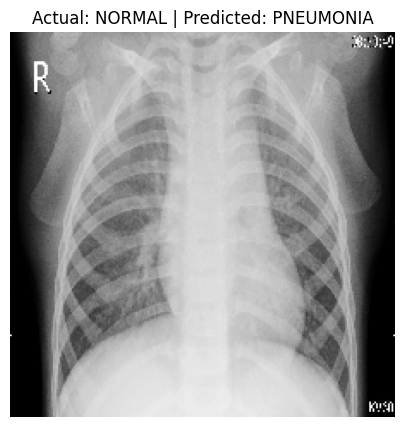

Prediction Score: 0.995743453502655
Using test_dir: chest_xray\test


In [55]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Load saved model if the in-memory model is unavailable (e.g., after kernel restart).
if "model" not in globals():
    model_path = OUTPUT_DIR / "best_model.keras"
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}. Run training first.")
    model = tf.keras.models.load_model(model_path)

# Prefer Kaggle path if available; otherwise use local dataset path.
kaggle_test_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"
local_test_dir = str(DATA_DIR / "test")
test_dir = kaggle_test_dir if os.path.exists(kaggle_test_dir) else local_test_dir

if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Test directory not found: {test_dir}")

# Randomly choose class and image.
class_name = random.choice(["NORMAL", "PNEUMONIA"])
class_path = os.path.join(test_dir, class_name)
img_list = sorted(os.listdir(class_path))

if not img_list:
    raise RuntimeError(f"No images found in: {class_path}")

img_name = random.choice(img_list)
img_path = os.path.join(class_path, img_name)

# Load and preprocess (must match training size).
img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict.
prediction = model.predict(img_array, verbose=0)
score = float(prediction[0][0])
pred_label = "PNEUMONIA" if score > 0.5 else "NORMAL"

# Show image and result.
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Actual: {class_name} | Predicted: {pred_label}")
plt.axis("off")
plt.show()

print("Prediction Score:", score)
print("Using test_dir:", test_dir)